<a href="https://colab.research.google.com/github/KamilEjaz890/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nTarget distribution:\n", df['Churn'].value_counts(normalize=True))

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 0

Target distribution:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [ ]:
# blank/whitespace strings dhoondo jo pandas ko null nahi dikh rahe
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print("Blank TotalCharges rows:", blank_mask.sum())
print(df[blank_mask][['customerID','tenure','MonthlyCharges','TotalCharges']])

Blank TotalCharges rows: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


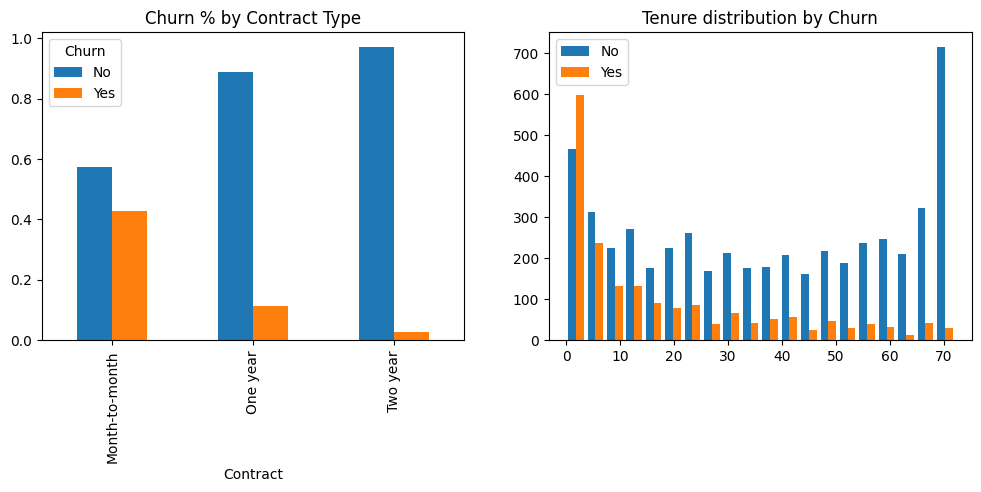

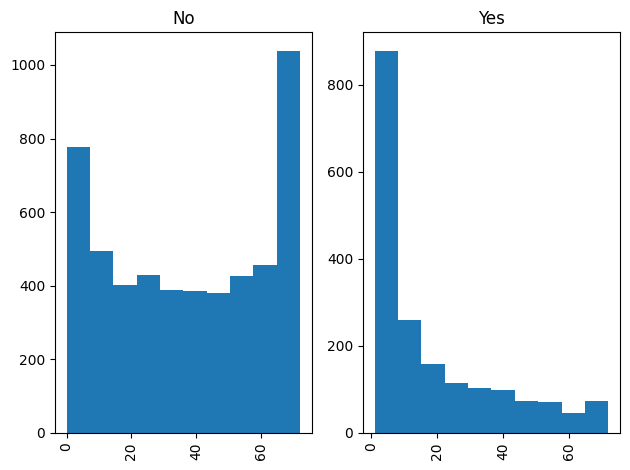

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar', ax=axes[0])
axes[0].set_title('Churn % by Contract Type')

df['tenure'].hist(by=df['Churn'], ax=axes[1] if False else None)
axes[1].hist([df[df.Churn=='No']['tenure'], df[df.Churn=='Yes']['tenure']], bins=20, label=['No','Yes'])
axes[1].set_title('Tenure distribution by Churn')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)   # tenure=0 -> 0 total charges

df = df.drop(columns=['customerID'])

In [ ]:
# collapse redundant categories: "No internet service" == InternetService=='No' ki hi info hai
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in service_cols:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# target encode
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# binary columns -> 0/1
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','MultipleLines'] + service_cols
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# multi-category -> one-hot (drop_first=True avoids "dummy variable trap")
df = pd.get_dummies(df, columns=['InternetService','Contract','PaymentMethod'], drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.shape)
df.head()

(7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])   # fit sirf train pe, test pe sirf transform

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1:       ", f1_score(y_test, y_pred))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba))
print("\n", classification_report(y_test, y_pred, target_names=['No Churn','Churn']))

Accuracy:  0.7402413058907026
Precision: 0.506896551724138
Recall:    0.786096256684492
F1:        0.6163522012578616
ROC-AUC:   0.8418739827946989

               precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['feature'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif.sort_values('VIF', ascending=False))

                                  feature        VIF
14                         MonthlyCharges  17.293415
15                           TotalCharges  10.990211
5                            PhoneService  10.264192
4                                  tenure   7.640881
16            InternetService_Fiber optic   7.605289
17                     InternetService_No   6.892019
19                      Contract_Two year   3.484411
11                            StreamingTV   3.108477
12                        StreamingMovies   3.061976
21         PaymentMethod_Electronic check   2.968748
13                       PaperlessBilling   2.958466
2                                 Partner   2.810048
6                           MultipleLines   2.670927
22             PaymentMethod_Mailed check   2.407504
9                        DeviceProtection   2.297816
8                            OnlineBackup   2.119423
10                            TechSupport   2.109520
18                      Contract_One year   2.

In [ ]:
X_train_v2 = X_train.drop(columns=['TotalCharges'])
X_test_v2 = X_test.drop(columns=['TotalCharges'])

model_v2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_v2.fit(X_train_v2, y_train)
y_proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]
print("ROC-AUC after removing TotalCharges:", roc_auc_score(y_test, y_proba_v2))

ROC-AUC after removing TotalCharges: 0.8387920121935467


In [ ]:
coefs = pd.DataFrame({'feature': X_train_v2.columns, 'coefficient': model_v2.coef_[0]})
coefs['odds_ratio'] = np.exp(coefs['coefficient'])
coefs['pct_change_in_odds'] = (coefs['odds_ratio'] - 1) * 100
coefs = coefs.sort_values('coefficient', ascending=False)

print("Increases churn odds:\n", coefs.head(6))
print("\nDecreases churn odds:\n", coefs.tail(6))

Increases churn odds:
                            feature  coefficient  odds_ratio  \
15     InternetService_Fiber optic     1.118833    3.061280   
20  PaymentMethod_Electronic check     0.399460    1.491019   
12                 StreamingMovies     0.392638    1.480883   
11                     StreamingTV     0.369054    1.446365   
13                PaperlessBilling     0.335803    1.399064   
6                    MultipleLines     0.322452    1.380509   

    pct_change_in_odds  
15          206.127980  
20           49.101908  
12           48.088288  
11           44.636519  
13           39.906351  
6            38.050906  

Decreases churn odds:
                feature  coefficient  odds_ratio  pct_change_in_odds
10         TechSupport    -0.274792    0.759730          -24.026991
7       OnlineSecurity    -0.342926    0.709691          -29.030934
17   Contract_One year    -0.720976    0.486277          -51.372261
4               tenure    -0.759712    0.467801          -53.219

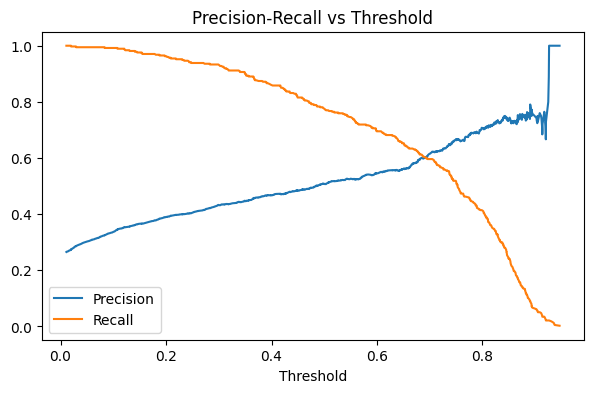

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_v2)

plt.figure(figsize=(7,4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.show()

In [ ]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1000, random_state=42)
model_l1.fit(X_train_v2, y_train)

l1_coefs = pd.Series(model_l1.coef_[0], index=X_train_v2.columns)
print("Features dropped by L1 (coefficient=0):\n", l1_coefs[l1_coefs == 0])

print("\nROC-AUC L1:", roc_auc_score(y_test, model_l1.predict_proba(X_test_v2)[:,1]))
print("ROC-AUC L2 (baseline):", roc_auc_score(y_test, y_proba_v2))

Features dropped by L1 (coefficient=0):
 DeviceProtection    0.0
MonthlyCharges      0.0
dtype: float64

ROC-AUC L1: 0.8391614353251182
ROC-AUC L2 (baseline): 0.8387920121935467


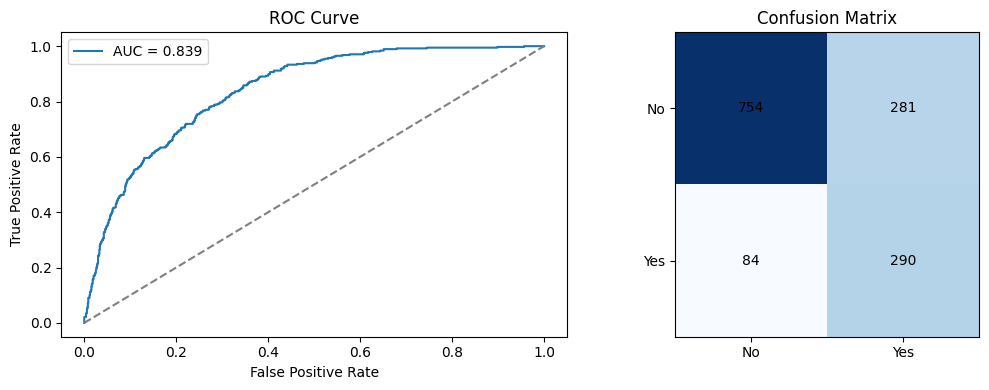

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba_v2)
cm = confusion_matrix(y_test, model_v2.predict(X_test_v2))

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba_v2):.3f}')
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

axes[1].imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i,j], ha='center', va='center')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['No','Yes']); axes[1].set_yticklabels(['No','Yes'])
axes[1].set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.1 MB/s eta 0:00:00
Best F1 threshold:     0.542  (F1=0.620)
Best Youden's J thresh: 0.417  (J=0.512)


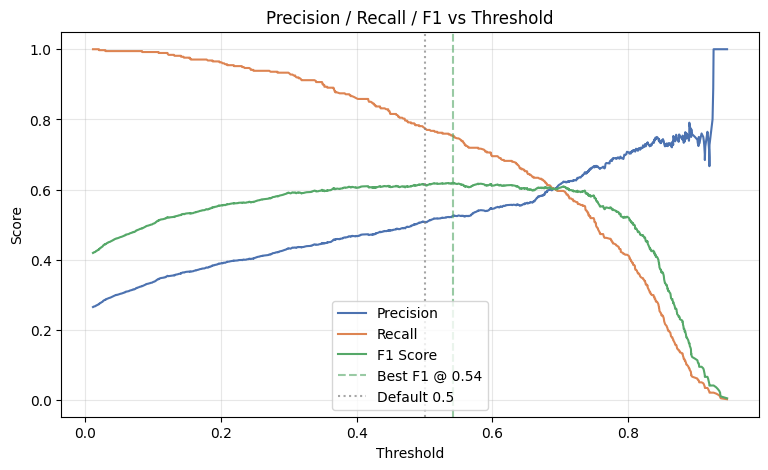

interactive(children=(FloatSlider(value=0.5, description='threshold', max=0.95, min=0.05, step=0.05), Output()…

<function __main__.explore_threshold(threshold=0.5)>

In [ ]:
!pip install ipywidgets -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix, roc_curve
import ipywidgets as widgets
from IPython.display import display

y_proba = model_v2.predict_proba(X_test_v2)[:, 1]

# ---- Compute metrics across thresholds ----
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_f1_idx = np.argmax(f1_scores[:-1])   # last point has no matching threshold
best_f1_threshold = pr_thresholds[best_f1_idx]

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
youden_j = tpr - fpr
best_youden_idx = np.argmax(youden_j)
best_youden_threshold = roc_thresholds[best_youden_idx]

print(f"Best F1 threshold:     {best_f1_threshold:.3f}  (F1={f1_scores[best_f1_idx]:.3f})")
print(f"Best Youden's J thresh: {best_youden_threshold:.3f}  (J={youden_j[best_youden_idx]:.3f})")

# ---- Static diagram: Precision/Recall/F1 vs Threshold ----
plt.figure(figsize=(9,5))
plt.plot(pr_thresholds, precisions[:-1], label='Precision', color='#4C72B0')
plt.plot(pr_thresholds, recalls[:-1], label='Recall', color='#DD8452')
plt.plot(pr_thresholds, f1_scores[:-1], label='F1 Score', color='#55A868')
plt.axvline(best_f1_threshold, color='#55A868', linestyle='--', alpha=0.6, label=f'Best F1 @ {best_f1_threshold:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default 0.5')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- Interactive slider: pick threshold, see confusion matrix + metrics live ----
def explore_threshold(threshold=0.5):
    y_pred_t = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    fig, axes = plt.subplots(1, 2, figsize=(11,4))

    axes[0].imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i,j], ha='center', va='center', fontsize=14)
    axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
    axes[0].set_xticklabels(['Pred No','Pred Yes']); axes[0].set_yticklabels(['True No','True Yes'])
    axes[0].set_title(f'Confusion Matrix @ threshold={threshold:.2f}')

    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0

    axes[1].bar(['Precision','Recall','F1'], [prec, rec, f1], color=['#4C72B0','#DD8452','#55A868'])
    axes[1].set_ylim(0,1)
    for idx, val in enumerate([prec, rec, f1]):
        axes[1].text(idx, val+0.02, f'{val:.2f}', ha='center')
    axes[1].set_title(f'Missed churners (FN)={fn}  |  False alarms (FP)={fp}')

    plt.tight_layout()
    plt.show()

widgets.interact(explore_threshold, threshold=widgets.FloatSlider(min=0.05, max=0.95, step=0.05, value=0.5))